In [3]:
import pyvista as pv
import nibabel as nib
import numpy as np

nii_file = "/Users/hippolyte.dreyfus/Desktop/hemianotACS/Data/derivatives/simnibs-config-healthyV2/0001/simulations/simulation_simulation_fef_hemianotacs_bc8ae6ee/mni_volumes/0001_TDCS_1_scalar_MNI_magnE.nii.gz"




In [4]:
# Charger nifti
img = nib.load(nii_file)
data = img.get_fdata()
data = np.squeeze(data)
print(data.shape)


(182, 218, 182)


/var/folders/_2/3kvbq9t123n4_87pldp32h7c0000gs/T/ipykernel_43160/4218719095.py:20: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show(screenshot="screenshot.png")


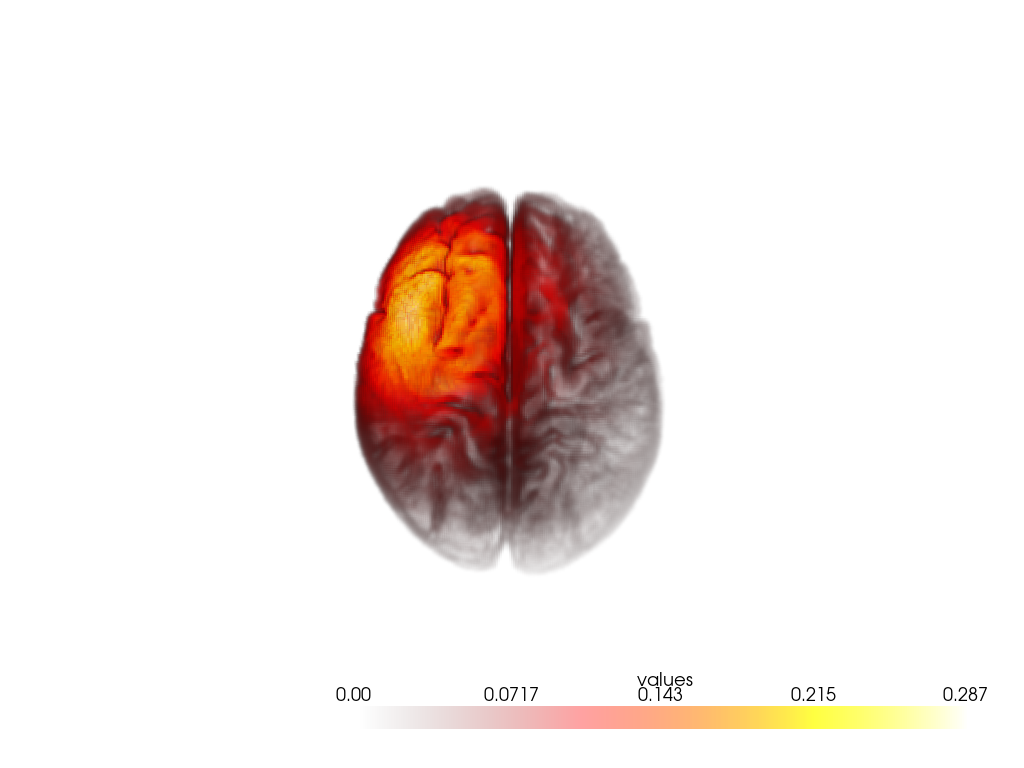

In [7]:
# Récupérer infos spatiales
affine = img.affine
spacing = img.header.get_zooms()[:3]
origin = affine[:3, 3]

# Créer grille
grid = pv.ImageData()

grid.dimensions = np.array(data.shape) + 1
grid.spacing = spacing
grid.origin = origin

# Ajouter données
grid.cell_data["values"] = data.flatten(order="F")

# Plot offscreen
plotter = pv.Plotter(off_screen=True)
plotter.add_volume(grid, cmap="hot")  # Colormap valide : hot, viridis, plasma, inferno, etc.
plotter.camera_position = 'xy'  # Vue depuis le haut (axe Z)
plotter.show(screenshot="screenshot.png")